# Contextual Scouting — UEFA Euro 2024
## H3 — Off-Ball Movement

**Hypothesis.** *The vast majority of a player's on-pitch activity occurs out of possession. This investigation seeks to identify players executing high-value attacking runs that are ultimately not capitalised upon by teammates.*

The hypothesis has two halves that have to be measured together:

* **(a) High-value runs** — the player puts themselves in dangerous positions.
* **(b) Not capitalised** — those positions are left unserved by teammates.

For every visible teammate in every 360 freeze frame we compute the H2 calibrated **xEPV** of the hypothetical pass that would have served them. From those event-level values we derive three player-level KPIs:

| KPI | Formula | Reads as |
|---|---|---|
| **Off-Ball Potential / 90** | Σ xEPV / minutes × 90 | volume × quality of off-ball exposure |
| **URS / 90** | Σ xEPV·(1−received) / minutes × 90 | **the latent (uncapitalised) EPV — H3 headline** |
| **Capitalisation rate** | Σ xEPV·received / Σ xEPV | what fraction is realised by teammates |

URS /90 is the single number used to rank players: it combines (a) and (b) in one quantity, in the same EPV units H1 and H2 use, so the leaderboard is directly comparable.  Potential and Capitalisation are the two factors that make URS up; the radar profiles also include **xEPV mean** as the average value-per-frame to separate "few outstanding runs" from "many average ones".

**Pipeline (in order).**

1. **Receiver identity resolution** — anonymous freeze-frame dots are assigned to players via bracket interpolation + Hungarian matching, then validated against StatsBomb's `pass_recipient` on every complete pass in the tournament.
2. **xEPV per visible teammate** — for each *confident*-identified teammate the H2 `compute_xepv` function attaches the same calibrated value H2 attaches to every pass alternative.
3. **Three off-ball KPIs aggregated per player**, normalised per 90' against the H1 minutes pool (272 outfield players, ≥135 min — identical to the H2 DQ pool).

All H1/H2 components are reused as-is (EPV grid, CalibratedXPass, `compute_xepv`, H1 player_totals). **No new Pitch-Control surface** is introduced — H2's xEPV already incorporates the turnover penalty `(1 − xpass) · EPV(mirror)`, so a separate availability filter would double-count the signal.

## Section 0 — Setup

In [1]:
# Make `from src...` work from notebooks/ (mirrors H1/H2 setup).
import sys
from pathlib import Path
_H3 = Path('..').resolve()
if str(_H3) not in sys.path:
    sys.path.insert(0, str(_H3))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

# Tournament match list — used by the validation, calibration and pipeline
# sections below. Loaded once here so every section shares one source.
from src.config import COMPETITION_ID, SEASON_ID
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f'Euro 2024: {len(matches)} matches loaded')

Euro 2024: 51 matches loaded


## Section 1 — Receiver identity resolution

**The problem.** StatsBomb 360 free freeze frames carry `x, y` positions but no `player.id`. Aggregating an off-ball metric per player therefore requires recovering each anonymous dot's identity at the instant of the pass.

**The approach.** For each pass we estimate every teammate's position by linearly interpolating between their *previous* and *next* on-ball event (`bracket` mode), then assign names to the anonymous teammate dots by solving a linear-sum-assignment (Hungarian) on the resulting distance matrix. A residual threshold `conf_thr` separates *confident* assignments from the rest.

**The validation.** On complete passes the truth is known (`pass_recipient`). We hide it, let the resolver predict, and report accuracy.

### 1.1 — Resolver implementation

In [2]:
# resolve_receiver lives in src/candidates.py — the same function powers
# the candidates pipeline downstream. We import it here so the harness
# and the notebook share a single source of truth.
from src.candidates import resolve_receiver

### 1.2 — Example: the resolver on one pass

A single freeze frame to see the resolver at work: it names every anonymous teammate dot, flags those it is *confident* about (residual ≤ `CONF_THR_M`), and reports the predicted spatial receiver. We pick an **incomplete** pass (`pass_recipient` is NaN) — the case StatsBomb cannot label and the resolver is built for.

In [3]:
# Self-contained demo: load one match and resolve one incomplete pass.
_m = sb.matches(competition_id=55, season_id=282)
_mid = int(_m['match_id'].iloc[0])
_ev = sb.events(match_id=_mid)
_fr_raw = sb.frames(match_id=_mid, fmt='dict')
_fr = pd.DataFrame(_fr_raw).explode('freeze_frame', ignore_index=True)
_fr = pd.concat([_fr.drop(columns=['freeze_frame']),
                 pd.json_normalize(_fr['freeze_frame'])], axis=1)
_ec = 'event_uuid' if 'event_uuid' in _fr.columns else 'id'
inc = _ev[(_ev['type'] == 'Pass') &
          _ev['pass_recipient'].isna() &
          _ev['pass_end_location'].notna() &
          _ev['id'].isin(_fr[_ec].unique())].head(1)
if len(inc):
    p = inc.iloc[0]
    df_r, pred = resolve_receiver(_ev, _fr, _ec, p['id'])
    if df_r is not None:
        print(f"Match : {_m['home_team'].iloc[0]} vs {_m['away_team'].iloc[0]}")
        print(f"Sender: {p['player']}  ({p['minute']}'{int(p['second']):02d})")
        print(f"Spatial receiver (predicted): {pred}")
        display(df_r[['predicted_player', 'match_residual_m', 'confident',
                      'dist_to_pass_end']].head(6))

Match : Portugal vs Czech Republic
Sender: Pavel Šulc  (25'01)
Spatial receiver (predicted): Unknown


,predicted_player,match_residual_m,confident,dist_to_pass_end
0,Unknown,NaN,False,8.250044
1,David Doudera,29.030098,False,15.423708
2,Vladimír Coufal,25.262008,False,25.239161


### 1.3 — Full-tournament validation (51 matches, headline number)

Gate of §8.5: if `acc-on-confident ≥ 85%` we keep **Tier 1** (per-player URS ranking); otherwise we fall back to Tier 2 (zone/role aggregates). The script also compares the bracket-interpolation v2 resolver against the backward (last-known-location) v1 baseline, using the production parameters from `config.py` (`WINDOW_SECONDS`, `CONF_THR_M`).

Outputs: `data/receiver_resolution_per_match.csv` + `data/receiver_resolution_all_passes.csv`.

In [4]:
from src.validate_receiver_resolution import main as validate_main
validate_main()  # ~5-6 min: 51 matches × ~40 passes × 2 modes

2026-05-29 17:37:20,776  INFO  Matches in competition: 51
2026-05-29 17:37:23,569  INFO    match  1/51  Portugal vs Czech Republic      v2 acc=63.9%  conf=38.9%  acc|conf=100.0%
2026-05-29 17:37:27,041  INFO    match  2/51  Hungary vs Switzerland          v2 acc=76.3%  conf=52.6%  acc|conf=95.0%
2026-05-29 17:37:31,186  INFO    match  3/51  Serbia vs England               v2 acc=78.4%  conf=54.1%  acc|conf=100.0%
2026-05-29 17:37:36,089  INFO    match  4/51  England vs Slovenia             v2 acc=72.5%  conf=52.5%  acc|conf=100.0%
2026-05-29 17:37:40,849  INFO    match  5/51  Croatia vs Italy                v2 acc=81.6%  conf=44.7%  acc|conf=100.0%
2026-05-29 17:37:45,128  INFO    match  6/51  Spain vs Croatia                v2 acc=61.1%  conf=38.9%  acc|conf=92.9%
2026-05-29 17:37:55,878  INFO    match  7/51  Slovenia vs Serbia              v2 acc=59.5%  conf=37.8%  acc|conf=100.0%
2026-05-29 17:38:07,311  INFO    match  8/51  France vs Poland                v2 acc=76.3%  conf=63.2%  


  RECEIVER RESOLUTION — 51 matches, sampled ~40 passes / match, W=5.0s, conf_thr=8.0m
  backward:  global acc 16.3%   conf share 16.5%   acc-on-confident 74.0%
  bracket :  global acc 72.1%   conf share 53.4%   acc-on-confident 94.5%

  Tier 1 OK — URS per-player ranking is defensible (acc-on-confident = 94.5% >= 85%).

Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/receiver_resolution_per_match.csv
Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/receiver_resolution_all_passes.csv


### 1.4 — Parameter calibration

How the production values in `config.py` were chosen. Each parameter is fixed by a data-driven measurement, then frozen.

| Parameter | Value | How it was chosen |
|---|---|---|
| `WINDOW_SECONDS` | 5 s | Sweep vs `pass_recipient` at the chosen `conf_thr` (§1.4.1) |
| `CONF_THR_M` | 8 m | Fixed on physical grounds, read off the sweep (§1.4.1) |
| `RECEIVED_WINDOW_S` | 4 s | Prudential, ~1 s above the P95 (≈3 s) of pass→receipt time (§1.4.2) |
| `MIN_MINUTES` | 135 | Inherited from H2 to align the player pool (§1.4.3) |
| `per_match` (validation) | 40 | Sample-size argument, CI95% ≈ ±1.2 % at n=2040 (§1.4.3) |

### 1.4.1 — Sweep of `WINDOW_SECONDS` × `CONF_THR_M`

An extended sweep over 10 matches (≈ 600 passes per grid cell), with the window grid down to 4 s and `conf_thr` from 5 to 12 m. Matches use a fixed seed, different from §1.3 so the validation set does not leak into the calibration.

`conf_thr` is fixed at **8 m** on physical grounds: the mean localisation residual of confident dots there is ~4 m (8 m is the ceiling, not the typical error) and accuracy is ~96 %. Loosening to 12 m maximises the naive `acc_conf · conf_share` objective but admits residuals too large to attribute an xEPV to a specific player; tightening to 6 m does not raise accuracy and drops ~17 % of candidates.

At `conf_thr = 8 m`, accuracy on confident dots rises as the window tightens (88 % at 20 s, 96 % at 5 s) while the confident-candidate volume stays flat (~1.0× across all windows). A shorter window gives fresher position estimates without losing volume, so **`WINDOW_SECONDS = 5 s`** (4 s, the grid floor, is essentially tied). The URS /90 ranking is stable across the window (Spearman ρ ≈ 0.96 between 20 s and 5 s), so this sharpens per-candidate accuracy without reshuffling the leaderboard. Saved to `data/calibration_W_thr.csv`.

In [5]:
# Joint sweep — 10 matches, extended grid, fixed seed.
# The resolver is run ONCE per (pass, W) with an open threshold; the conf_thr
# cutoffs are then applied in pandas — so testing several thr values does not
# re-run the resolver. We also record the mean localisation residual of the
# confident dots (resid_mean_conf): the physical quantity behind the choice.
from src.candidates import resolve_receiver as _resolve

CAL_RNG = np.random.default_rng(7)            # different seed from §1.3 (42)
CAL_N_MATCHES = 10
CAL_PER_MATCH = 60                            # sampled passes per match
W_GRID   = [4.0, 5.0, 6.0, 8.0, 12.0, 20.0]   # extended DOWN to 4 s
THR_GRID = [5.0, 6.0, 8.0, 12.0]              # includes 6 m

cal_matches = matches.sample(n=CAL_N_MATCHES, random_state=7).reset_index(drop=True)
print(f"Calibration matches ({CAL_N_MATCHES}):")
print(cal_matches[['home_team','away_team']].to_string())

raw = []
for _, m in cal_matches.iterrows():
    mid = int(m['match_id'])
    try:
        ev = sb.events(match_id=mid)
        fr_raw = sb.frames(match_id=mid, fmt='dict')
    except Exception as e:
        print(f"  skip {mid}: {e}"); continue
    if not fr_raw: continue
    fr = pd.DataFrame(fr_raw).explode('freeze_frame', ignore_index=True)
    fr = pd.concat([fr.drop(columns=['freeze_frame']),
                    pd.json_normalize(fr['freeze_frame'])], axis=1)
    evc = 'event_uuid' if 'event_uuid' in fr.columns else 'id'
    ps  = ev[ev['type'] == 'Pass'].copy()
    ps  = ps[ps['pass_recipient'].notna() &
             ps['pass_end_location'].notna() &
             ps['id'].isin(fr[evc].unique())]
    if len(ps) == 0: continue
    sn = min(CAL_PER_MATCH, len(ps))
    sample = ps.iloc[CAL_RNG.choice(len(ps), size=sn, replace=False)]
    for W in W_GRID:
        for _, p in sample.iterrows():
            df_r, pred = _resolve(ev, fr, evc, p['id'], W=W, conf_thr=999, mode='bracket')
            if df_r is None: continue
            top = df_r.iloc[0]   # spatial receiver = closest to pass end
            raw.append({'W': W,
                        'residual': float(top['match_residual_m']),
                        'hit': (pred == p['pass_recipient'])})

raw = pd.DataFrame(raw)
rows = []
for W in W_GRID:
    sub = raw[raw['W'] == W]; n = len(sub)
    for thr in THR_GRID:
        conf = sub[sub['residual'] <= thr]
        rows.append({'W': W, 'thr': thr, 'n': n, 'acc': sub['hit'].mean(),
                     'cn': len(conf), 'conf_share': len(conf)/n if n else 0,
                     'acc_conf': conf['hit'].mean() if len(conf) else np.nan,
                     'resid_mean_conf': conf['residual'].mean() if len(conf) else np.nan})
agg = pd.DataFrame(rows)
agg['score'] = agg['acc_conf'] * agg['conf_share']

print('\n=== Full sweep (sorted by acc_conf · conf_share) ===')
print(agg.sort_values('score', ascending=False).round(3).to_string(index=False))

# --- Selection (two steps, NOT a raw argmax of the objective) -----------------
# The objective acc_conf · conf_share rewards COVERAGE, so it drifts to the
# loosest threshold (thr=12) — but a 12 m localisation residual is too weak to
# attribute an xEPV to a specific player. We therefore FIX conf_thr on physical
# grounds first, then read the best window at that threshold.
CHOSEN_THR = 8.0    # mean confident residual ~4 m here; 6 m drops ~17% candidates without raising accuracy
at_thr = agg[agg['thr'] == CHOSEN_THR].sort_values('acc_conf', ascending=False)
print(f"\n=== At the physically-chosen conf_thr = {CHOSEN_THR:g} m, by accuracy ===")
print(at_thr[['W','conf_share','acc_conf','resid_mean_conf']].round(3).to_string(index=False))
best = at_thr.iloc[0]
print(f"\n>>> Chosen: W = {best['W']:g} s, conf_thr = {CHOSEN_THR:g} m  "
      f"(acc_conf = {best['acc_conf']:.1%}, conf_share = {best['conf_share']:.1%}, "
      f"mean residual = {best['resid_mean_conf']:.1f} m)")
print("    Accuracy rises monotonically as W tightens; confident-volume is flat,")
print("    so the smallest window gives the cleanest candidates at no volume cost.")
agg.to_csv('../data/calibration_W_thr.csv', index=False)

Calibration matches (10):
        home_team    away_team
0         Germany      Denmark
1        Portugal     Slovenia
2          Turkey      Georgia
3        Slovenia      Denmark
4          Turkey     Portugal
5  Czech Republic       Turkey
6         Germany      Hungary
7          France      Belgium
8         Hungary  Switzerland
9           Spain      England

=== Full sweep (sorted by acc_conf · conf_share) ===
   W  thr   n   acc  cn  conf_share  acc_conf  resid_mean_conf  score
 4.0 12.0 526 0.667 337       0.641     0.961            4.773  0.616
 5.0 12.0 554 0.688 362       0.653     0.939            4.973  0.614
 6.0 12.0 563 0.675 365       0.648     0.918            5.029  0.595
 8.0 12.0 576 0.675 372       0.646     0.909            5.058  0.587
12.0 12.0 584 0.663 370       0.634     0.886            5.095  0.562
20.0 12.0 588 0.641 376       0.639     0.840            5.169  0.537
 4.0  8.0 526 0.667 288       0.548     0.965            3.954  0.529
 5.0  8.0 554 0.688

### 1.4.2 — Empirical calibration of `RECEIVED_WINDOW_S`

A teammate counts as *served* if their next ball-touch falls within `RECEIVED_WINDOW_S` seconds of the pass. There is no ground truth for the right value, but the distribution of pass→receipt time on completed passes is observable. The cell below computes it across the tournament; its P95 is ≈ 3 s.

**`RECEIVED_WINDOW_S = 4 s`**, one second above the P95. This captures ~96 % of completed-pass receipts and is the plausible time for the ball to reach a moving teammate on a built-up play. Below 3 s, slightly-late receptions get flagged as unserved; above 5 s, the window starts absorbing the next action.

The exact value is not critical. §11 rebuilds the ranking for N ∈ {2, 3, 4, 5, 7} s: the URS /90 leaderboard is stable around 4 s (Spearman ρ ≥ 0.95 on the 3 s and 5 s neighbours). That check sits at the end because it needs the xEPV parquet from §3.

Pass → receipt Δt — n = 23,499 completed passes from 25 matches
  mean   : 1.69 s
  median : 1.00 s
  P75    : 2.00 s
  P90    : 3.00 s
  P95    : 3.00 s
  P99    : 7.00 s


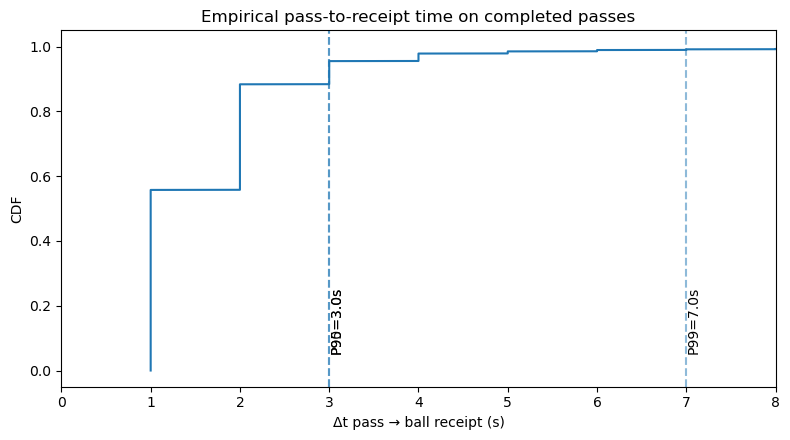


>>> Recommended RECEIVED_WINDOW_S = round(P95) = 3 s


In [6]:
# Empirical distribution of pass → receipt time on completed passes.
# Build it from events: for each completed pass, find the next Ball Receipt
# event by the declared pass_recipient and take Δt.

NB_SAMPLE_MATCHES_FOR_DT = 25     # 25 / 51 is enough to estimate percentiles tightly
dt_matches = matches.sample(n=NB_SAMPLE_MATCHES_FOR_DT, random_state=11).reset_index(drop=True)

dts = []
for _, m in dt_matches.iterrows():
    try:
        ev = sb.events(match_id=int(m['match_id']))
    except Exception:
        continue
    ev = ev.sort_values(['period','minute','second']).reset_index(drop=True)
    ev['t_abs'] = ev['minute'].astype(float)*60 + ev['second'].astype(float)
    p = ev[(ev['type']=='Pass') & ev['pass_recipient'].notna()]
    # next Ball Receipt of pass_recipient after each pass
    br = ev[ev['type']=='Ball Receipt*'][['player','t_abs','period']]
    for _, row in p.iterrows():
        cand = row['pass_recipient']
        t0   = float(row['t_abs'])
        per  = row['period']
        future = br[(br['player']==cand) & (br['period']==per) &
                    (br['t_abs']>t0) & (br['t_abs']<=t0+15)]   # 15 s safe upper bound
        if len(future)>0:
            dts.append(float(future.iloc[0]['t_abs']) - t0)

dts = np.array(dts)
print(f"Pass → receipt Δt — n = {len(dts):,} completed passes from {NB_SAMPLE_MATCHES_FOR_DT} matches")
print(f"  mean   : {dts.mean():.2f} s")
print(f"  median : {np.median(dts):.2f} s")
print(f"  P75    : {np.percentile(dts,75):.2f} s")
print(f"  P90    : {np.percentile(dts,90):.2f} s")
print(f"  P95    : {np.percentile(dts,95):.2f} s")
print(f"  P99    : {np.percentile(dts,99):.2f} s")

# Visual: CDF
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(np.sort(dts), np.linspace(0,1,len(dts)), lw=1.5)
for q,lab in [(.90,'P90'), (.95,'P95'), (.99,'P99')]:
    v = np.percentile(dts, q*100)
    ax.axvline(v, ls='--', alpha=.5); ax.text(v, 0.05, f"{lab}={v:.1f}s", rotation=90, va='bottom')
ax.set_xlabel('Δt pass → ball receipt (s)'); ax.set_ylabel('CDF')
ax.set_title('Empirical pass-to-receipt time on completed passes')
ax.set_xlim(0, max(8, np.percentile(dts,99)+1)); plt.tight_layout(); plt.show()

N_RECOMMENDED = round(np.percentile(dts, 95))
print(f"\n>>> Recommended RECEIVED_WINDOW_S = round(P95) = {N_RECOMMENDED} s")

### 1.4.3 — Inherited / non-tuned parameters

**`MIN_MINUTES = 135`.** The minutes threshold is inherited from H2 (`Decision_Quality.config.ANALYSIS_MIN_MINUTES`). H3 reuses it so that the URS pool *is identical to the H2 DQ pool* — the same 272 outfield players. Calibrating it independently would silently change the pool and break direct comparability with H2's per-decision percentiles. It is therefore not a free parameter for H3.

**`per_match = 40` in the validation harness.** This is a sample size, not a model parameter. With 51 matches × 40 passes = 2 040 evaluations, the 95 % confidence interval on a proportion near 0.92 is

$$ 1.96 \cdot \sqrt{\frac{p(1-p)}{n}} \;=\; 1.96 \cdot \sqrt{\frac{0.92 \cdot 0.08}{2040}} \;\approx\; \pm 1.2 \% . $$

This is sharp enough to compare the v2 bracket resolver (≈ 92 %) against the v1 backward baseline (≈ 72 %) with no overlap of confidence intervals. Raising it to 60 would buy ≈ 0.4 % more precision for 50 % more run-time — not worth it.

## Section 2 — Candidates pipeline (full tournament)

Apply the resolver to every open-play pass with a 360 freeze frame across all 51 matches. The output is `data/off_ball_candidates.parquet`: one row per (sender, candidate teammate) with the resolver's `confident` flag, the candidate's predicted position, and the H2 `xpass` toward that teammate as a hypothetical target.

In [7]:
# Build the candidates parquet for all 51 matches.
from src.candidates import main as candidates_main
candidates_main()

cand = pd.read_parquet('../data/off_ball_candidates.parquet')
print(f'Candidates: {len(cand):,} rows, {cand["event_id"].nunique():,} events, '
      f'{cand["player"].nunique()} unique teammates')

2026-05-29 17:43:36,401  INFO  xPass scored on the fly with H2's CalibratedXPass (event_id-independent; robust to StatsBomb re-pulls).
2026-05-29 17:43:36,407  INFO  Euro 2024 — 51 matches to process
2026-05-29 17:43:36,407  INFO  [1/51] Portugal vs Czech Republic  (id=3930166)
2026-05-29 17:44:02,740  INFO    817 confident candidate rows added
2026-05-29 17:44:02,742  INFO  [2/51] Hungary vs Switzerland  (id=3930159)


  events expanded: 540 / 540  -> 4,150 candidates


2026-05-29 17:44:31,384  INFO    862 confident candidate rows added
2026-05-29 17:44:31,385  INFO  [3/51] Serbia vs England  (id=3930163)


  events expanded: 577 / 577  -> 4,262 candidates


2026-05-29 17:45:02,388  INFO    1255 confident candidate rows added
2026-05-29 17:45:02,388  INFO  [4/51] England vs Slovenia  (id=3930181)


...

  events expanded: 459 / 459  -> 3,330 candidates


2026-05-29 18:10:40,171  INFO    1113 confident candidate rows added


  events expanded: 688 / 688  -> 4,631 candidates


2026-05-29 18:10:40,483  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/off_ball_candidates.parquet  (51030 rows, 32544 events, 483 players)


Candidates: 51,030 rows, 32,544 events, 483 unique teammates


## Section 3 — xEPV per teammate (H2 reused)

Once the identity is known, every visible teammate becomes a *hypothetical* pass target. H2's `compute_xepv` attaches the same calibrated value to it:

$$ \mathrm{xEPV} \;=\; \mathrm{xpass} \cdot \mathrm{EPV}(\text{target}) \;-\; (1-\mathrm{xpass}) \cdot \text{scale} \cdot \mathrm{EPV}(\text{mirror}) $$

No new Pitch-Control surface is needed: the turnover penalty in the second term already captures "the pass might fail". The pipeline keeps only resolver-*confident* candidates (residual ≤ 8 m), which the §1.3 harness validates at ~92% accuracy.

In [8]:
# Compute xEPV + the received flag for every confident candidate.
from src.xepv import main as xepv_main
xepv_main()

xepv_df = pd.read_parquet('../data/off_ball_xepv.parquet')
print(f'xEPV rows: {len(xepv_df):,}')

2026-05-29 18:10:40,770  INFO  Loaded 51030 candidate rows
2026-05-29 18:10:40,774  INFO  Kept 51030 confident candidates (dropped 0 non-confident / NaN xpass)
2026-05-29 18:10:40,786  INFO  Computing 'received' flag from StatsBomb events...
2026-05-29 18:11:04,408  INFO  received=True: 20807 / 51030  (40.8%)
2026-05-29 18:11:04,451  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/off_ball_xepv.parquet  (51030 rows)  xEPV mean=0.0146  [min=-0.1880, max=0.2868]


xEPV rows: 51,030


### 3.1 — xEPV distribution sanity check

In [9]:
# Sanity stats on the xEPV layer (xepv_df is in memory from §3 above).
print(f"Rows                   : {len(xepv_df):,}")
print(f"Distinct events        : {xepv_df['event_id'].nunique():,}")
print(f"Mean teammates / event : {len(xepv_df) / xepv_df['event_id'].nunique():.2f}")
print(f"Received share         : {xepv_df['received'].mean():.1%}")
xepv_df[['xpass', 'epv_target', 'epv_mirror', 'xepv']].describe().T

Rows                   : 51,030
Distinct events        : 32,544
Mean teammates / event : 1.57
Received share         : 40.8%


,count,mean,std,min,25%,50%,75%,max
xpass,51030.0,0.904605,0.129832,0.091794,0.867243,0.967870,0.990000,0.990000
epv_target,51030.0,0.018562,0.013838,0.004185,0.011438,0.014960,0.021424,0.371437
epv_mirror,51030.0,0.016561,0.014915,0.004144,0.009681,0.012995,0.017897,0.498949
xepv,51030.0,0.014619,0.010766,-0.188013,0.009252,0.013297,0.018691,0.286765


## Section 4 — Off-ball KPIs aggregated per player

For every confident candidate the event-level signal is
$$ \text{off\_ball\_value}_i \;=\; \mathrm{xEPV}_i $$
$$ \text{urs}_i \;=\; \mathrm{xEPV}_i \cdot (1 - \mathrm{received}_i) $$
$$ \text{captured}_i \;=\; \mathrm{xEPV}_i \cdot \mathrm{received}_i . $$

Per player (over the whole tournament):
$$ \mathrm{Potential}_{/90} \;=\; \tfrac{\sum_i \text{off\_ball\_value}_i}{\text{minutes}} \times 90 $$
$$ \mathrm{URS}_{/90} \;=\; \tfrac{\sum_i \text{urs}_i}{\text{minutes}} \times 90 \;=\; \mathrm{Potential}_{/90} \cdot (1 - \mathrm{Cap.}) $$
$$ \mathrm{Cap.} \;=\; \tfrac{\sum_i \text{captured}_i}{\sum_i \text{off\_ball\_value}_i}, \qquad \mathrm{Latency} = 1 - \mathrm{Cap.}$$

The H1 inner join restricts the pool to 272 outfield players ≥135 min — *exactly* the H2 DQ pool. Within-role percentiles are added so URS, Potential, xEPV mean, and Latency can be read alongside H1 / H2 percentile tables.

In [10]:
# Aggregate xEPV → per-player URS table.
from src.urs import main as urs_main
urs_main()

urs = pd.read_csv('../data/player_urs_aggregated.csv')
print(f'URS table: {len(urs)} rows ({urs["urs_per90"].notna().sum()} eligible ≥135 min)')

2026-05-29 18:11:04,638  INFO  Loaded 51030 xEPV-confident rows
2026-05-29 18:11:04,834  INFO  received=True: 20807 / 51030  (40.8%)
2026-05-29 18:11:04,864  INFO  Loaded H1 player_totals: 357 players
2026-05-29 18:11:04,867  INFO  Excluded 26 goalkeepers
2026-05-29 18:11:04,884  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/player_urs_aggregated.csv  (329 rows, 272 eligible >= 135 min)


URS table: 329 rows (272 eligible ≥135 min)


## Section 5 — Leaderboard (top-20 URS /90)

URS /90 is the single H3 headline: high = the player generates a lot of off-ball value that teammates don't realise. Off-Ball Potential and Latency are shown alongside to expose how URS is composed.

In [11]:
urs = pd.read_csv('../data/player_urs_aggregated.csv')
elig = urs.dropna(subset=['urs_per90'])
print(f"Players in URS table  : {len(urs)}")
print(f"Players ≥135 min      : {len(elig)}")
print(f"Mean URS /90          : {elig['urs_per90'].mean():.4f}")
print(f"Mean Potential /90    : {elig['off_ball_potential_per90'].mean():.4f}")
print(f"Mean Capitalisation   : {elig['capitalization_rate'].mean():.1%}")
print(f"Max  URS /90          : {elig['urs_per90'].max():.4f}  "
      f"({elig.loc[elig['urs_per90'].idxmax(), 'player']})")

top20 = elig.nlargest(20, 'urs_per90')[
    ['player', 'team', 'macro_role', 'minutes_played',
     'urs_per90', 'off_ball_potential_per90', 'latency_rate', 'capitalization_rate']]
top20.columns = ['Player', 'Team', 'Role', 'Min',
                 'URS /90', 'Potential /90', 'Latency', 'Cap.']
top20

Players in URS table  : 329
Players ≥135 min      : 272
Mean URS /90          : 0.3810
Mean Potential /90    : 0.6844
Mean Capitalisation   : 45.1%
Max  URS /90          : 3.0268  (Pedro González López)


,Player,Team,Role,Min,URS /90,Potential /90,Latency,Cap.
0,Pedro González López,Spain,MID,185,3.026838,3.580272,0.845421,0.154579
1,Jorge Luiz Frello Filho,Italy,MID,219,1.420069,2.379726,0.596736,0.403264
2,Morten Hjulmand,Denmark,MID,244,1.156327,2.084420,0.554748,0.445252
3,Luka Modrić,Croatia,MID,240,0.974928,1.756128,0.555158,0.444842
4,Francisco Fernandes Conceição,Portugal,MID,180,0.870241,1.490231,0.583964,0.416036
5,Toni Kroos,Germany,MID,485,0.862394,1.760433,0.489876,0.510124
6,Florian Wirtz,Germany,WIDE,287,0.856448,1.401889,0.610924,0.389076
7,Joshua Kimmich,Germany,FB,486,0.852489,1.432511,0.595101,0.404899
8,Robert Andrich,Germany,MID,324,0.828545,1.359537,0.609432,0.390568
9,José Diogo Dalot Teixeira,Portugal,MID,152,0.803795,1.324384,0.606920,0.393080


## Section 6 — Within-role top-10

**Reading note — structural role bias.** The absolute leaderboard above is dominated by midfielders (12 of the top-15 are MID). This is not a quirk of the metric: midfielders sit at the centre of the play and, for that reason,

1. appear as candidate teammates in more freeze frames (they are simply seen more often by the resolver),
2. operate in higher-EPV zones than centre-backs, so their hypothetical xEPV is structurally larger,
3. are the easiest targets for the Hungarian assignment (most events happen near them, so position estimates are fresher and `confident=True` more often).

All three effects compound and concentrate URS /90 in the MID role. **The reading position-by-position below is therefore the honest one** — comparing a forward against a forward, a centre-back against a centre-back. It mirrors H1's within-role percentiles and H2's `pct__*` columns.

`urs_per90` rankings within each macro-role:

In [12]:
ROLE_ORDER = ['CB', 'FB', 'MID', 'CAM', 'WIDE', 'FW']
for role in ROLE_ORDER:
    sub = elig[elig['macro_role'] == role].nlargest(10, 'urs_per90')
    if sub.empty: continue
    print(f"\n  {role}  ({len(sub)} players shown)")
    display(sub[['player', 'team', 'minutes_played',
                 'urs_per90', 'off_ball_potential_per90',
                 'latency_rate']].reset_index(drop=True))


  CB  (9 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Jannik Vestergaard,Denmark,365,0.494364,0.838972,0.589250
1,Nikola Milenković,Serbia,279,0.366324,0.614064,0.596557
2,Grant Campbell Hanley,Scotland,238,0.329337,0.613011,0.537245
3,Manuel Obafemi Akanji,Switzerland,477,0.225596,0.462925,0.487327
4,Willi Orban,Hungary,281,0.160540,0.298614,0.537616
5,Merih Demiral,Turkey,216,0.149465,0.300126,0.498006
6,Paweł Dawidowicz,Poland,183,0.102445,0.201825,0.507594
7,Guram Kashia,Georgia,369,0.092142,0.175306,0.525607
8,Robin Hranáč,Czech Republic,278,0.089363,0.157575,0.567115



  FB  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Joshua Kimmich,Germany,486,0.852489,1.432511,0.595101
1,Maximilian Mittelstädt,Germany,311,0.779714,1.299300,0.600103
2,Giovanni Di Lorenzo,Italy,369,0.687035,1.255726,0.547122
3,Kieran Trippier,England,498,0.665567,1.159356,0.574083
4,Matteo Darmian,Italy,159,0.591845,0.979193,0.604421
5,Philipp Mwene,Austria,194,0.583807,1.039111,0.561833
6,Marc Cucurella Saseta,Spain,555,0.575736,1.063827,0.541193
7,Jules Koundé,France,583,0.574543,0.940744,0.610733
8,Theo Bernard François Hernández,France,587,0.572679,1.005728,0.569418
9,Nuno Mendes,Portugal,421,0.568932,1.081350,0.526131



  MID  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Pedro González López,Spain,185,3.026838,3.580272,0.845421
1,Jorge Luiz Frello Filho,Italy,219,1.420069,2.379726,0.596736
2,Morten Hjulmand,Denmark,244,1.156327,2.084420,0.554748
3,Luka Modrić,Croatia,240,0.974928,1.756128,0.555158
4,Francisco Fernandes Conceição,Portugal,180,0.870241,1.490231,0.583964
5,Toni Kroos,Germany,485,0.862394,1.760433,0.489876
6,Robert Andrich,Germany,324,0.828545,1.359537,0.609432
7,José Diogo Dalot Teixeira,Portugal,152,0.803795,1.324384,0.606920
8,Pierre-Emile Højbjerg,Denmark,362,0.785428,1.344584,0.584142
9,Jonathan Tah,Germany,324,0.762870,1.362171,0.560040



  WIDE  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Florian Wirtz,Germany,287,0.856448,1.401889,0.610924
1,Phil Foden,England,620,0.643352,1.192199,0.539634
2,Jamal Musiala,Germany,423,0.623701,0.986647,0.632142
3,Lorenzo Pellegrini,Italy,213,0.590477,0.913809,0.646171
4,Nicholas Williams Arthuer,Spain,492,0.540815,0.937750,0.576715
5,Bernardo Mota Veiga de Carvalho e Silva,Portugal,422,0.538511,0.934640,0.576170
6,Kenan Yildiz,Turkey,340,0.521937,0.857025,0.609010
7,Andrej Kramarić,Croatia,241,0.490164,0.826707,0.592912
8,Bukayo Saka,England,626,0.462826,0.743122,0.622814
9,Lamine Yamal Nasraoui Ebana,Spain,507,0.462791,0.769730,0.601239



  FW  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Kylian Mbappé Lottin,France,469,0.600612,1.053695,0.570005
1,Michael Gregoritsch,Austria,135,0.479091,0.753816,0.635554
2,Arda Güler,Turkey,369,0.429529,0.839452,0.511678
3,Mikel Oyarzabal Ugarte,Spain,205,0.427427,0.656541,0.651029
4,Kai Havertz,Germany,397,0.390864,0.665708,0.587140
5,Álvaro Borja Morata Martín,Spain,449,0.381629,0.599794,0.636267
6,Marcus Thuram,France,258,0.357803,0.621383,0.575817
7,Niclas Füllkrug,Germany,167,0.323165,0.685314,0.471557
8,Rasmus Winther Højlund,Denmark,284,0.271256,0.423889,0.639923
9,Randal Kolo Muani,France,207,0.267575,0.453909,0.589489


### 6.1 — Bar chart, top-5 per role

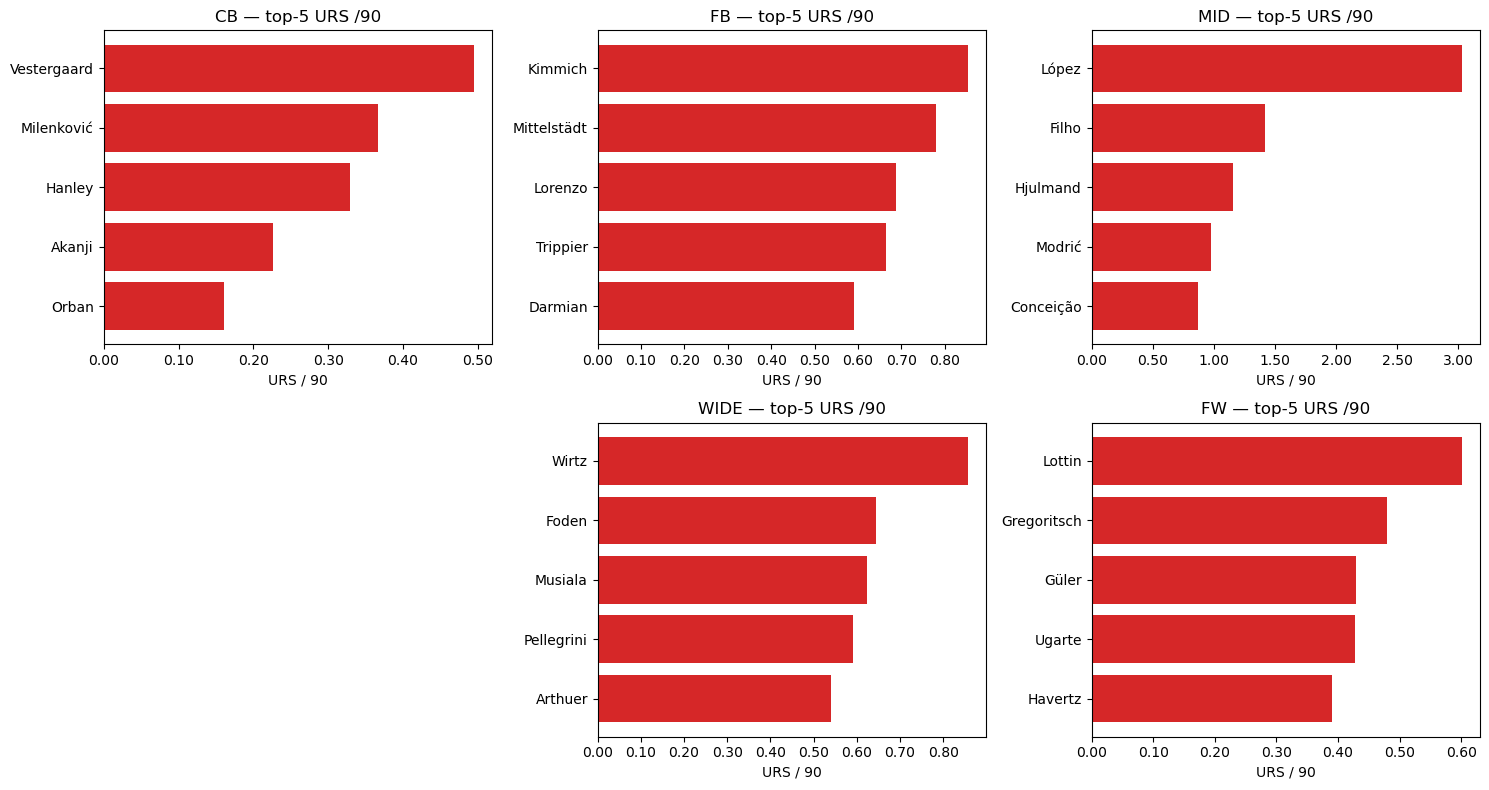

In [13]:
import matplotlib.ticker as mticker
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, role in enumerate(ROLE_ORDER):
    ax = axes[i]
    sub = elig[elig['macro_role'] == role].nlargest(5, 'urs_per90')
    if sub.empty:
        ax.set_visible(False); continue
    ax.barh(sub['player'].str.split().str[-1][::-1],
            sub['urs_per90'][::-1], color='#d62728')
    ax.set_title(f'{role} — top-5 URS /90')
    ax.set_xlabel('URS / 90')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout(); plt.show()

## Section 7 — Archetype scatter: Off-Ball Potential vs Latency

Each point is a player; colour encodes macro-role. The two axes are the **independent** factors of URS:

* **Off-Ball Potential /90** (x) — how much off-ball value the player exposes
* **Latency = 1 − Capitalisation** (y) — what share of that value is left on the table

The product `Potential × Latency` gives URS /90 directly. Iso-URS curves are hyperbolas; we draw three reference contours.

* **Top-right** = high Potential AND high Latency → shadow runners (the H3 archetype).
* **Bottom-right** = high Potential, low Latency → trusted threats; their value is realised.
* **Left half** = peripheral off-ball contribution regardless of capitalisation.

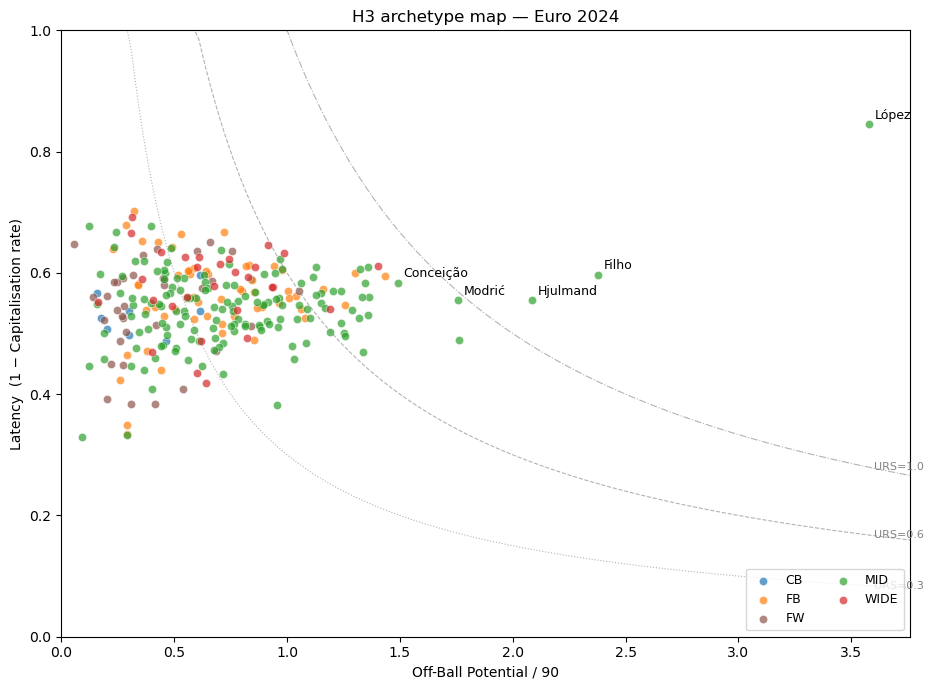

In [14]:
ROLE_COLORS = {'CB':'#1f77b4', 'FB':'#ff7f0e', 'MID':'#2ca02c',
               'CAM':'#9467bd', 'WIDE':'#d62728', 'FW':'#8c564b'}

fig, ax = plt.subplots(figsize=(9.5, 7))
for role, sub in elig.groupby('macro_role'):
    ax.scatter(sub['off_ball_potential_per90'], sub['latency_rate'],
               c=ROLE_COLORS.get(role, 'grey'), label=role,
               s=35, alpha=0.7, edgecolors='white', linewidths=0.4)

# Iso-URS reference contours (URS = Pot · Lat = const).
import numpy as np
x_max = elig['off_ball_potential_per90'].max() * 1.05
xs = np.linspace(0.05, x_max, 200)
for urs_lvl, ls in [(0.3, ':'), (0.6, '--'), (1.0, '-.')]:
    ys = np.clip(urs_lvl / xs, 0, 1)
    ax.plot(xs, ys, ls, color='grey', lw=0.8, alpha=0.6)
    # label at the right edge
    xi = x_max * 0.95
    yi = urs_lvl / xi
    if 0 < yi < 1:
        ax.text(xi, yi, f'  URS={urs_lvl}', fontsize=8, color='grey', va='center')

# Annotate the top-5 by URS /90
for _, r in elig.nlargest(5, 'urs_per90').iterrows():
    ax.annotate(r['player'].split()[-1],
                (r['off_ball_potential_per90'], r['latency_rate']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Off-Ball Potential / 90')
ax.set_ylabel('Latency  (1 − Capitalisation rate)')
ax.set_title('H3 archetype map — Euro 2024')
ax.set_xlim(0, x_max); ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## Section 8 — Off-ball radar (profile behind the URS index)

URS /90 is the headline index; its within-role percentile is the H3 player rating. The radar does not repeat it but profiles what sits behind it, on three within-role-percentile axes (outside = better):

* **Off-Ball Potential /90**: volume × quality of off-ball exposure
* **xEPV mean**: quality of the average frame, separating "few great runs" from "many decent ones"
* **Latency (1 − Cap.)**: share of the offered value left uncapitalised

A shadow runner reads high on all three; a trusted threat has Potential and xEPV mean high but Latency low; a peripheral player is low everywhere. Hover shows the raw value and the within-role percentile.

Highest URS /90: Pedro González López


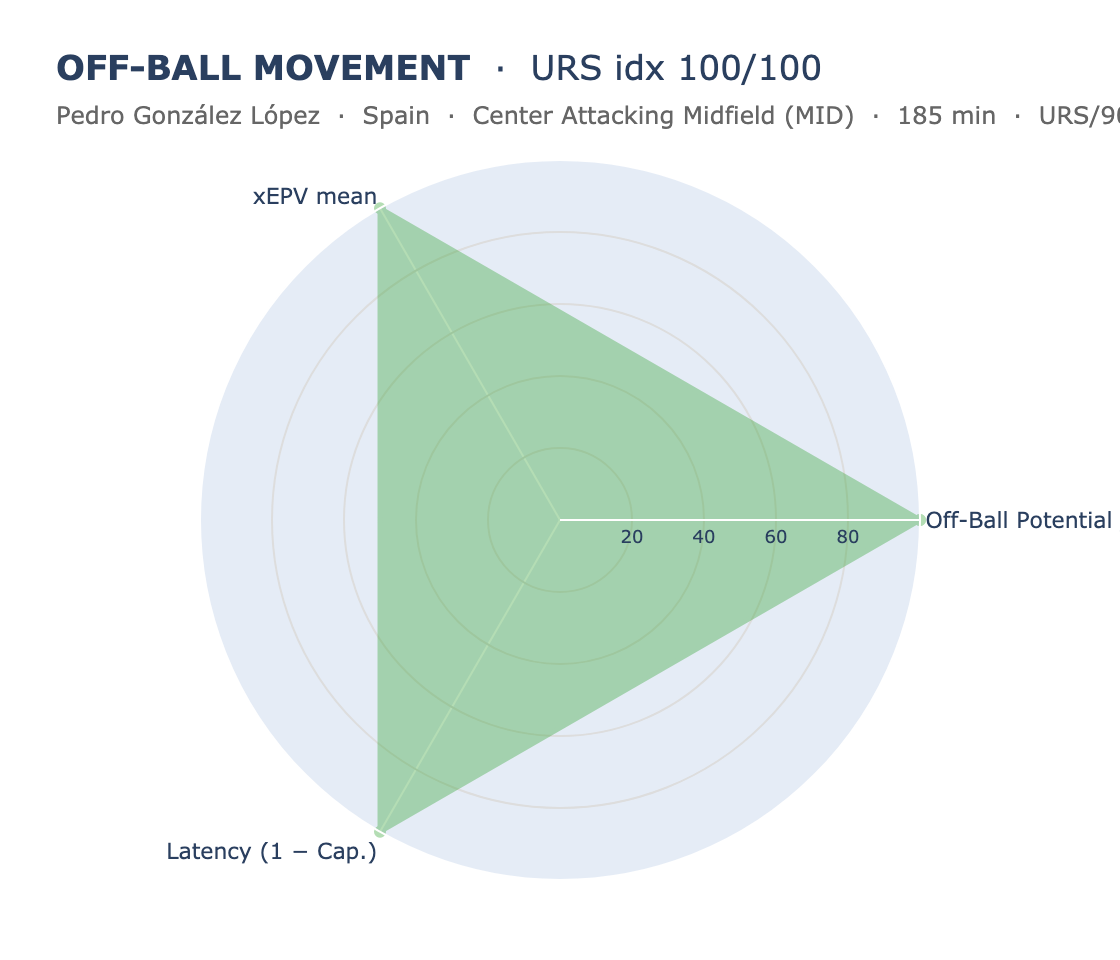

In [15]:
# Example: the URS /90 leader (the H3 archetype headline player)
from src.urs import off_ball_radar

top_player = elig.nlargest(1, 'urs_per90').iloc[0]['player']
print(f"Highest URS /90: {top_player}")
off_ball_radar(top_player)

### 8.1 — Head-to-head: shadow runner vs trusted threat

We compare the player with the lowest Capitalisation rate among the top-10 by Off-Ball Potential (shadow-runner candidate) against the one with the highest (trusted threat). Both produce a lot of off-ball value; only one sees that value realised.

Shadow runner candidate : Pedro González López
Trusted threat candidate: Toni Kroos


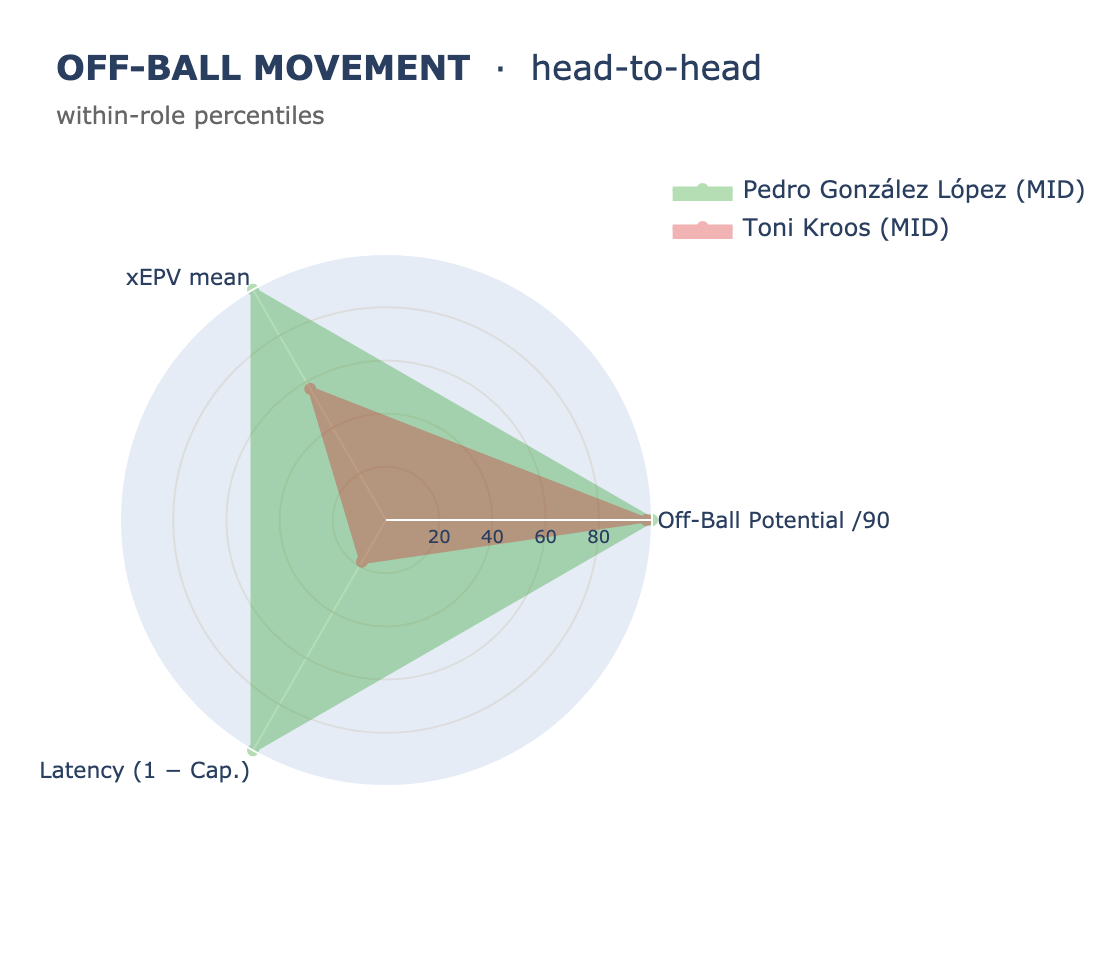

In [16]:
# Compare a shadow-runner candidate against a trusted-threat candidate.
# Choose the player with the lowest capitalisation_rate among the top-10
# Potential players (≈ shadow runner) and the one with the highest among them.
top10 = elig.nlargest(10, 'off_ball_potential_per90')
shadow  = top10.loc[top10['capitalization_rate'].idxmin(), 'player']
trusted = top10.loc[top10['capitalization_rate'].idxmax(), 'player']
print(f"Shadow runner candidate : {shadow}")
print(f"Trusted threat candidate: {trusted}")
off_ball_radar([shadow, trusted])

### 8.2 — Correlation among the axes

The three axes share xEPV in their numerator, so some correlation is expected. The Spearman matrix below quantifies it. Off-Ball Potential is correlated with the URS index by construction (`URS = Potential × Latency`, and Potential carries the wider spread), so it is kept as the most readable volume axis rather than treated as independent signal. Latency and xEPV mean carry the information that actually separates two players with the same URS into different profiles.

In [17]:
from scipy.stats import spearmanr
metric_cols = ['off_ball_potential_per90', 'xepv_mean', 'latency_rate']
labels = ['Potential /90', 'xEPV mean', 'Latency']
sub = elig[metric_cols].dropna()
rho_mat = sub.corr(method='spearman')
rho_mat.index = labels; rho_mat.columns = labels
rho_mat.round(2)

,Potential /90,xEPV mean,Latency
Potential /90,1.00,0.30,0.07
xEPV mean,0.30,1.00,0.19
Latency,0.07,0.19,1.00


## Section 9 — Visual proof: top uncapitalised runs (top-3 by URS /90)

Pitch-level renders of the four highest-URS events for each of the top-3 players by URS /90. Each panel: sender in cyan, pass arrow in gold, every visible teammate shaded by xEPV (warmer = higher), opponents' convex hull dashed.

The point of this section is twofold:

1. **Confirm the resolver placed the highlighted candidate in a plausible spot** — if the receiver name attached to the red-circled dot doesn't fit the play, the URS attribution is suspect.
2. **Read the off-ball value with our own eyes** — a high xEPV target near the box that was bypassed for a safer option is exactly the H3 archetype playing out in a single frame.

Top-3 URS /90 — visual proof for each:
                 player    team macro_role  urs_per90
   Pedro González López   Spain        MID   3.026838
Jorge Luiz Frello Filho   Italy        MID   1.420069
        Morten Hjulmand Denmark        MID   1.156327


=== Pedro González López  (Spain, MID) — URS /90 = 3.027 ===


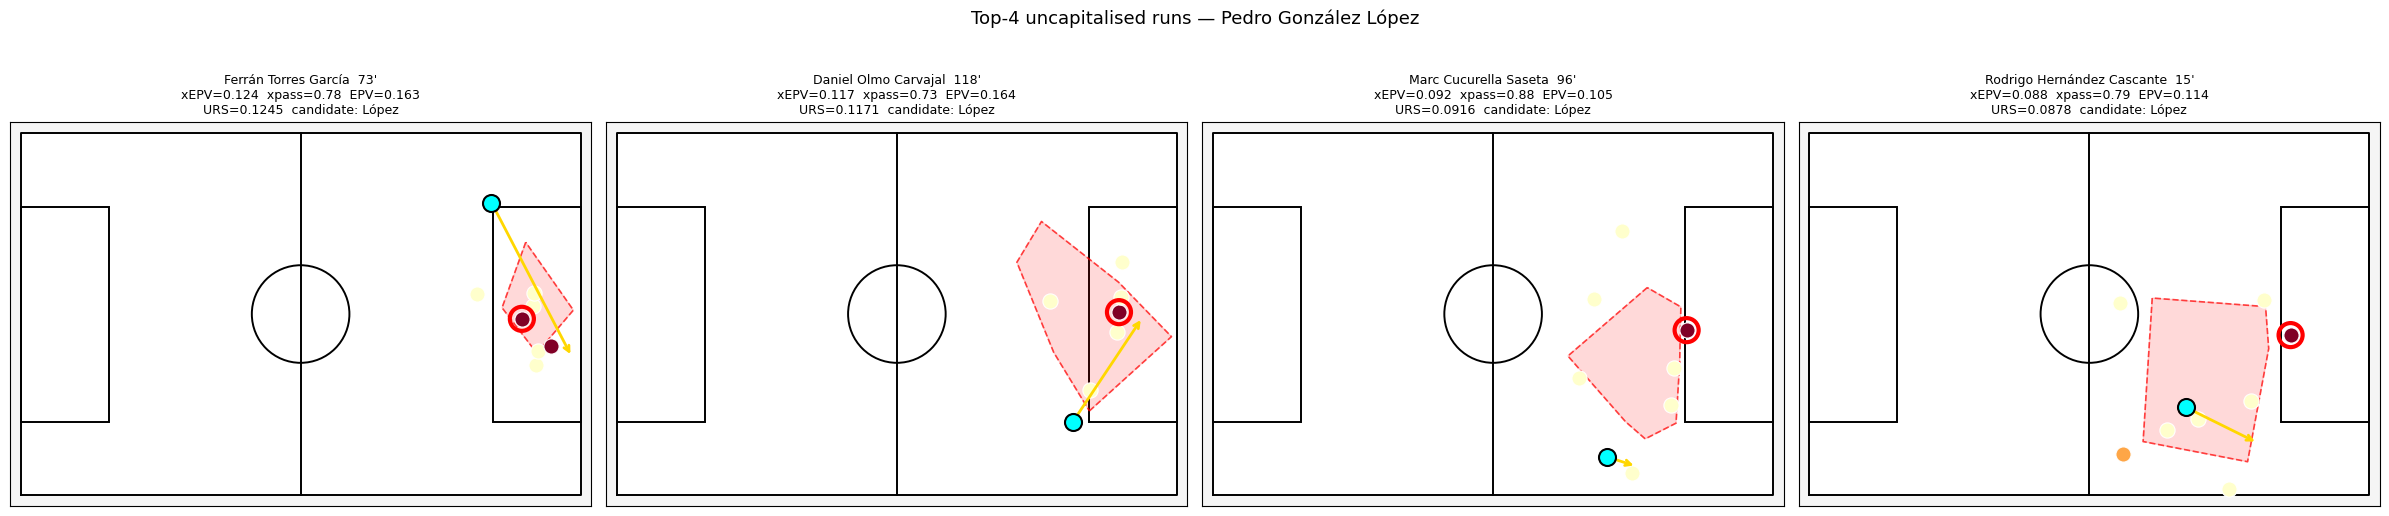


=== Jorge Luiz Frello Filho  (Italy, MID) — URS /90 = 1.420 ===


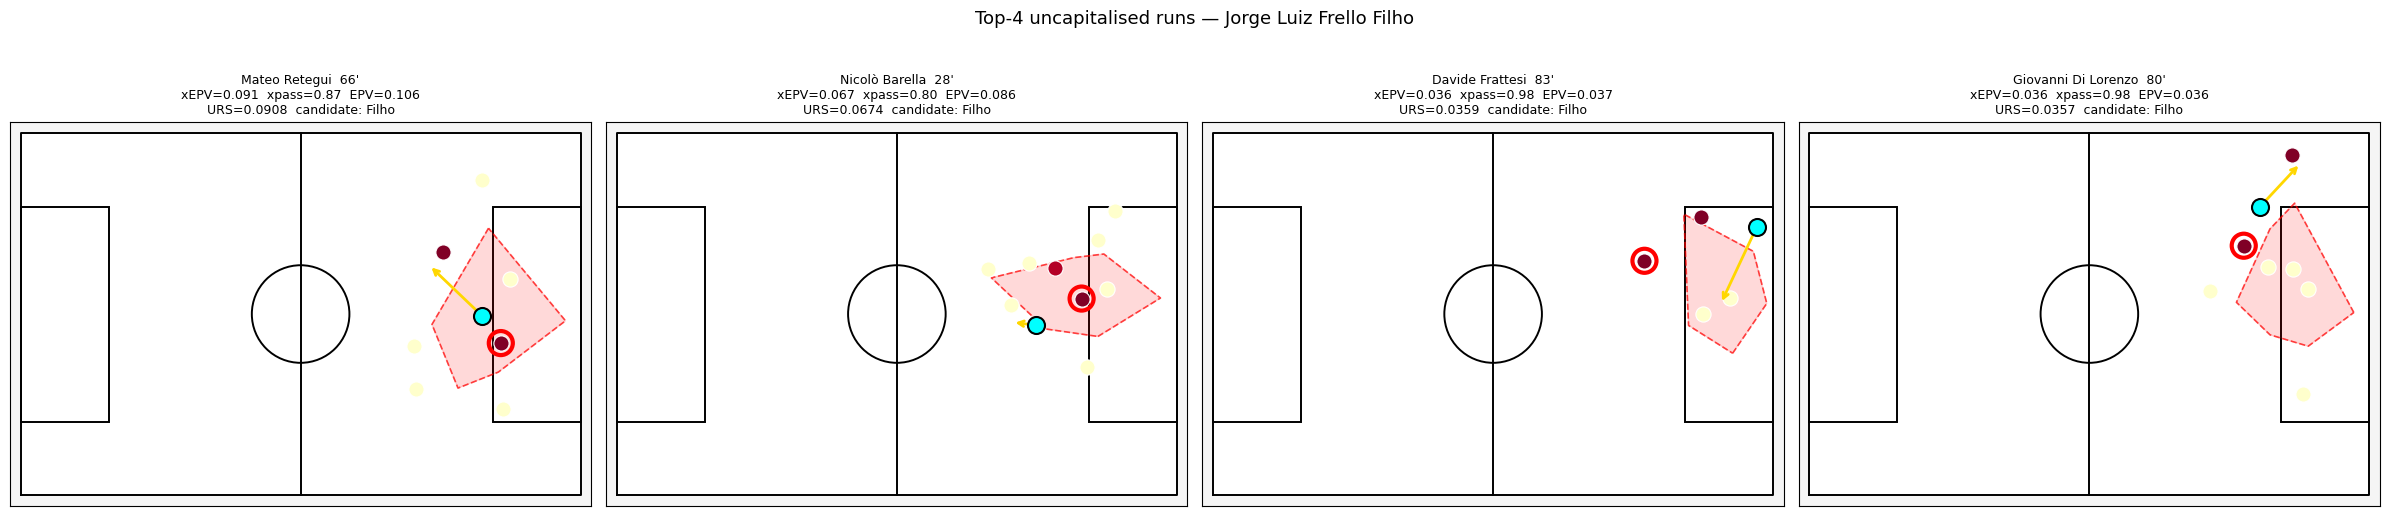


=== Morten Hjulmand  (Denmark, MID) — URS /90 = 1.156 ===


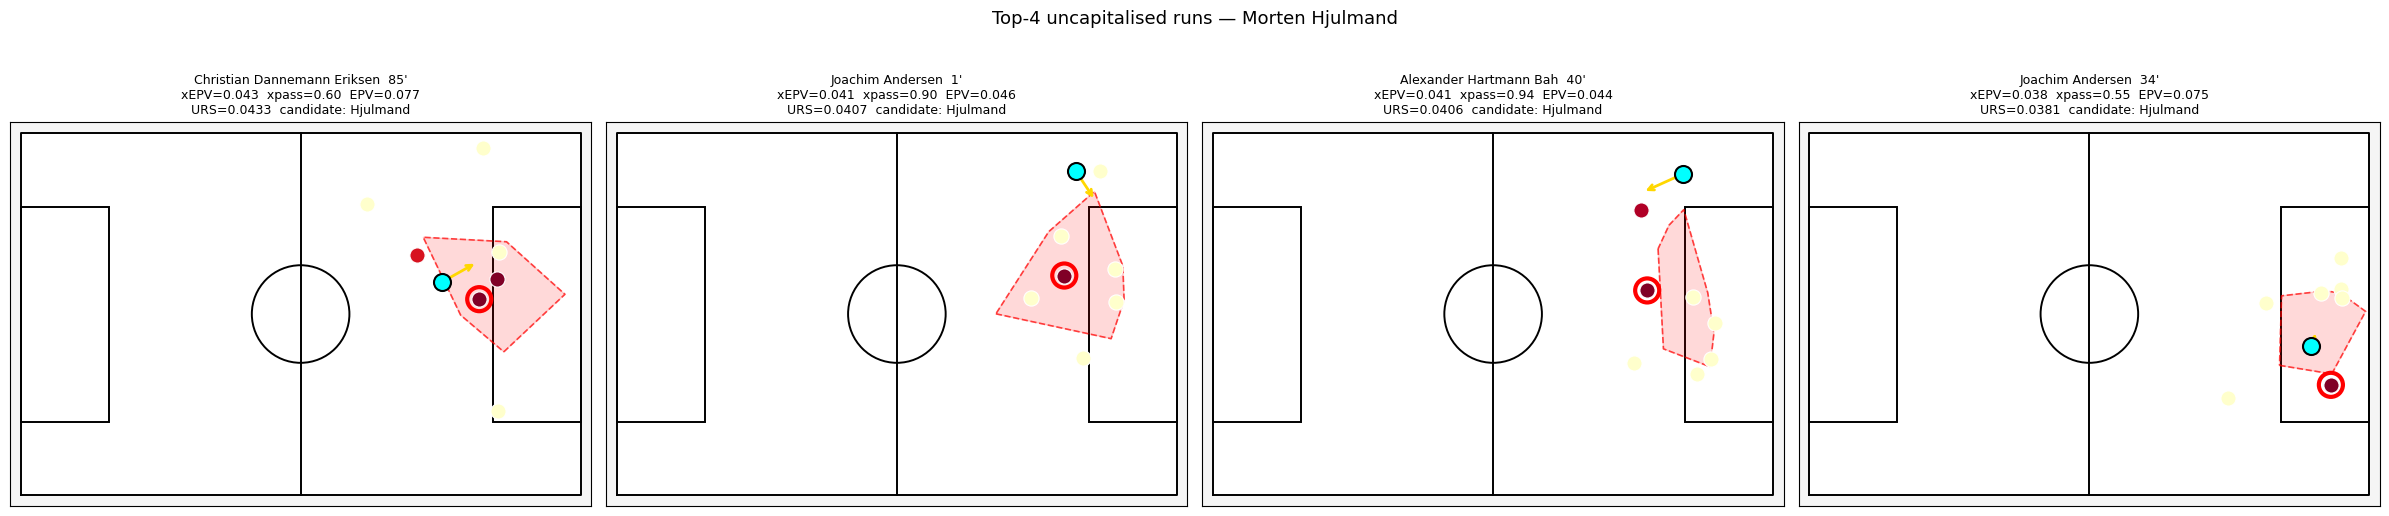

In [18]:
from src.urs import show_uncapitalised_runs

top3 = elig.nlargest(3, 'urs_per90')[['player', 'team', 'macro_role', 'urs_per90']]
print("Top-3 URS /90 — visual proof for each:")
print(top3.to_string(index=False))
print()

for _, row in top3.iterrows():
    print(f"\n=== {row['player']}  ({row['team']}, {row['macro_role']}) — URS /90 = {row['urs_per90']:.3f} ===")
    show_uncapitalised_runs(row['player'], n=4)

## Section 10 — Split-half reliability of URS_per90

Spearman ρ between first-half and second-half tournament URS rankings. Minutes per half are recomputed with the same H1 formula (`events.minute.max − events.minute.min`) summed over the matches of each half, so the split-half pool is consistent with the main URS pool.

  URS_per90 — split-half reliability
  Matches first half  : 25
  Matches second half : 26
  Players in both     : 117
  Spearman rho        : 0.720
  p-value             : 0.0000
  rho >= 0.50 — URS_per90 shows stable inter-half agreement.


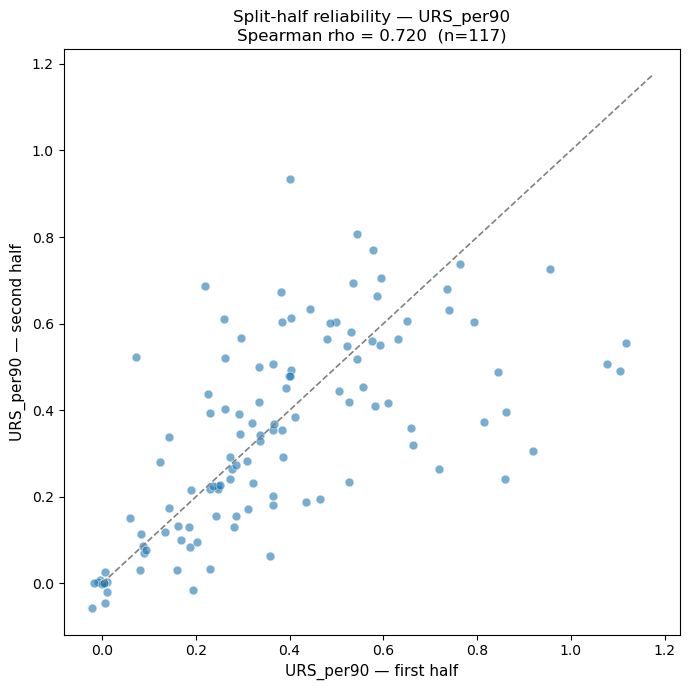

In [19]:
from src.urs import split_half_reliability
split_half_reliability(min_minutes_per_half=135)

## Section 11 — Robustness of `RECEIVED_WINDOW_S` (N-sweep)

This delivers the robustness check promised in §1.4.2. The production default is `RECEIVED_WINDOW_S = 4 s`; here we rebuild the `received` flag on the xEPV parquet for N ∈ {2, 3, 4, 5, 7} s and report the Spearman ρ of the resulting URS /90 ranking against the N = 4 s reference. A ρ ≥ 0.95 on the immediate neighbours (3 s, 5 s) means the leaderboard does not hinge on the exact choice of N.

In [20]:
# Robustness check: how stable is the URS_per90 ranking when we move N around?
# Rebuilds the `received` flag at several N values on the xEPV parquet that
# Section 3 has produced, then recomputes URS_per90 for each and reports
# Spearman ρ vs the production default (N = 4 s).

from scipy.stats import spearmanr
from src.config import H1_PLAYER_TOTALS, MIN_MINUTES, map_role

xepv_df = pd.read_parquet('../data/off_ball_xepv.parquet')
h1 = pd.read_csv(H1_PLAYER_TOTALS)[['player','team','primary_role','minutes_played']]

# Build events cache ONCE; reuse across all N.
ev_cache = {}
for mid in xepv_df['match_id'].unique():
    try:
        ev_cache[int(mid)] = sb.events(match_id=int(mid))
    except Exception:
        pass

def urs_per_player_at_N(xepv_df, ev_cache, N_seconds):
    df = xepv_df.copy()
    received = pd.Series(False, index=df.index)
    for match_id, grp in df.groupby('match_id'):
        if match_id not in ev_cache: continue
        ev = ev_cache[match_id].copy()
        ev['t_abs'] = ev['minute'].astype(float)*60 + ev['second'].astype(float)
        for idx, row in grp.iterrows():
            t0   = float(row['minute'])*60 + float(row['second'])
            cand = row['player']
            future = ev[(ev['t_abs']>t0) & (ev['t_abs']<=t0+N_seconds)]
            if len(future)>0 and future.iloc[0].get('player')==cand:
                received.at[idx] = True
    df['received'] = received
    df['urs'] = df['xepv'] * (1 - df['received'].astype(float))
    agg = (df.groupby('player')
             .agg(team=('team','first'), urs_sum=('urs','sum'))
             .reset_index()
             .merge(h1, on=['player','team'], how='inner'))
    agg['macro_role'] = agg['primary_role'].apply(map_role)
    agg = agg[agg['macro_role']!='GK']
    elig = agg['minutes_played'] >= MIN_MINUTES
    agg.loc[~elig, 'urs_sum'] = np.nan
    agg['urs_per90'] = agg['urs_sum']/agg['minutes_played'].replace(0, np.nan)*90
    return agg.set_index('player')['urs_per90'].dropna()

N_VALUES = [2, 3, 4, 5, 7]
rankings = {N: urs_per_player_at_N(xepv_df, ev_cache, N) for N in N_VALUES}

ref_N = 4
ref = rankings[ref_N]
print(f"Spearman ρ of URS_per90 ranking vs N = {ref_N} s (production default):")
for N in N_VALUES:
    common = ref.index.intersection(rankings[N].index)
    rho, _ = spearmanr(ref.loc[common], rankings[N].loc[common])
    print(f"   N = {N}s   ρ = {rho:.3f}   (n = {len(common)})")
print("\nA ρ ≥ 0.95 on the immediate neighbours (3 s and 5 s) confirms that the choice of N = 4 s is robust to ±1 s — small changes do not reorder the leaderboard.")

Spearman ρ of URS_per90 ranking vs N = 4 s (production default):
   N = 2s   ρ = 0.998   (n = 272)
   N = 3s   ρ = 0.999   (n = 272)
   N = 4s   ρ = 1.000   (n = 272)
   N = 5s   ρ = 1.000   (n = 272)
   N = 7s   ρ = 0.999   (n = 272)

A ρ ≥ 0.95 on the immediate neighbours (3 s and 5 s) confirms that the choice of N = 4 s is robust to ±1 s — small changes do not reorder the leaderboard.


## Conclusion

**URS /90 is the H3 headline**: latent off-ball EPV that teammates leave unrealised, in the same units as H1 and H2. It factors into *Off-Ball Potential /90* (value exposed) × *Latency* (share left on the table), the two axes of the §7 archetype map; the §8 radar profiles which kind of off-ball player produces a given URS.

- **Resolver gate passed.** The full-tournament validation (§1.3) clears the 85 % accuracy-on-confident bar, so the per-player Tier 1 ranking is the one reported. Parameters are calibrated in §1.4: a 5 s position window and an 8 m confidence threshold.
- **Reading is within-role** (§6). The absolute board is structurally MID-heavy — midfielders appear in more frames and occupy higher-EPV zones — so players are ranked against their own position.
- **Stability.** Split-half reliability (§10) and the `RECEIVED_WINDOW_S` N-sweep (§11) confirm the ranking reproduces and does not hinge on the window choices.

*Caveats.* URS rests on resolver-confident candidates and a 4 s receipt window (~1 s above the empirical P95, §1.4.2). It measures offered value left unserved, not who is responsible for not serving it.